# 09 · 最终模型结果

> O2O 优惠券个性化投放项目 —— 第 9 步

---

## 本节目标

用第 08 节的最终特征集建模，产出**可信的模型指标**，并与 v1 的虚高结果做对照。

## 一个容易忽略的细节：超参该在哪选

第 04 节的超参是在**有泄漏的数据**上搜索出来的——那批超参「擅长利用泄漏」，
用在无泄漏特征上未必合适。所以本节**在无泄漏验证段上重新搜索超参**：

- 搜索方式：手动遍历参数网格，每个组合在训练段拟合、在**验证段（6 月）**评估
- 选择标准：验证段 AUC

这样做比「在训练段做交叉验证」更贴近真实场景——**用历史训练、用未来选型**。

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
import joblib

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
MODEL_DIR = OUT_DIR / 'models_final'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

## 1. 读取最终特征表

In [2]:
train = pd.read_csv(OUT_DIR / 'final_train.csv')
val = pd.read_csv(OUT_DIR / 'final_val.csv')
test = pd.read_csv(OUT_DIR / 'final_test.csv')

FEATURES = [c for c in train.columns if c != 'class']
Xtr, ytr = train[FEATURES], train['class']
Xva, yva = val[FEATURES], val['class']
Xte = test[FEATURES]

print(f'训练段: {train.shape}   验证段: {val.shape}   测试段: {test.shape}')
print(f'特征数: {len(FEATURES)}')
print(f'验证段正样本率: {yva.mean() * 100:.2f}%')

spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
print(f'scale_pos_weight: {spw:.2f}')

训练段: (865468, 20)   验证段: (81811, 20)   测试段: (100669, 23)
特征数: 19
验证段正样本率: 6.99%
scale_pos_weight: 15.86


## 2. 决策树：在验证段上搜索超参

In [3]:
dt_grid = {
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [50, 100, 200],
    'min_samples_leaf': [20, 50, 100],
}

def to_native(v):
    """numpy 标量 -> Python 原生类型。

    两个容易踩的坑：
      1. 浮点参数【不能】走 int()：learning_rate=0.05 会被截断成 0，模型完全不学习（AUC 恰好 0.5）
      2. 取值要用 df.loc[0, k] 而非 df.iloc[0][k]：后者会把一行的 int 列和 float 列
         向上转型成 float，导致 max_depth 变成 5.0 而被 sklearn 拒绝
    """
    if isinstance(v, (bool, np.bool_)):
        return bool(v)
    if isinstance(v, np.integer):
        return int(v)
    if isinstance(v, np.floating):
        return float(v)
    return v


dt_rows = []
t0 = time.time()
for params in ParameterGrid(dt_grid):
    m = DecisionTreeClassifier(**params, random_state=42, class_weight='balanced')
    m.fit(Xtr, ytr)
    auc = roc_auc_score(yva, m.predict_proba(Xva)[:, 1])
    dt_rows.append({**params, 'val_auc': auc})

dt_res = pd.DataFrame(dt_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
dt_res.to_csv(TAB_DIR / '09_gridsearch_dt_final.csv', index=False)
dt_best_params = {k: to_native(dt_res.loc[0, k]) for k in dt_grid}

print(f'搜索 {len(dt_res)} 组，耗时 {time.time() - t0:.0f}s')
print(f'最优参数: {dt_best_params}')
print(f'验证段最优 AUC: {dt_res.iloc[0]["val_auc"]:.4f}')
print()
print('Top 5 组合：')
print(dt_res.head().round(4).to_string(index=False))

搜索 36 组，耗时 164s
最优参数: {'max_depth': 5, 'min_samples_split': 50, 'min_samples_leaf': 20}
验证段最优 AUC: 0.5987

Top 5 组合：
 max_depth  min_samples_leaf  min_samples_split  val_auc
         5                20                 50   0.5987
         5                20                100   0.5987
         5                20                200   0.5987
         5                50                 50   0.5987
         5                50                100   0.5987


In [4]:
dt_best = DecisionTreeClassifier(**dt_best_params, random_state=42, class_weight='balanced')
dt_best.fit(Xtr, ytr)
pred_dt = dt_best.predict(Xva)
prob_dt = dt_best.predict_proba(Xva)[:, 1]

m_dt = {'AUC': roc_auc_score(yva, prob_dt), 'Accuracy': accuracy_score(yva, pred_dt),
        'Precision': precision_score(yva, pred_dt), 'Recall': recall_score(yva, pred_dt),
        'F1': f1_score(yva, pred_dt)}
print('决策树（验证段 6 月）：')
for k, v in m_dt.items():
    print(f'  {k:<10} {v:.4f}')

决策树（验证段 6 月）：
  AUC        0.5987
  Accuracy   0.8249
  Precision  0.1428
  Recall     0.3010
  F1         0.1937


## 3. XGBoost：在验证段上搜索超参

In [5]:
xgb_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
}

xgb_rows = []
t0 = time.time()
for i, params in enumerate(ParameterGrid(xgb_grid), 1):
    m = xgb.XGBClassifier(**params, subsample=0.8, colsample_bytree=0.8, random_state=42,
                          n_jobs=-1, scale_pos_weight=spw, eval_metric='auc')
    m.fit(Xtr, ytr)
    auc = roc_auc_score(yva, m.predict_proba(Xva)[:, 1])
    xgb_rows.append({**params, 'val_auc': auc})
    print(f'  [{i:>2}/{len(ParameterGrid(xgb_grid))}] {params}  val_auc={auc:.4f}', flush=True)

xgb_res = pd.DataFrame(xgb_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
xgb_res.to_csv(TAB_DIR / '09_gridsearch_xgb_final.csv', index=False)
xgb_best_params = {k: to_native(xgb_res.loc[0, k]) for k in xgb_grid}

print()
print(f'搜索耗时 {time.time() - t0:.0f}s')
print(f'最优参数: {xgb_best_params}')
print(f'验证段最优 AUC: {xgb_res.iloc[0]["val_auc"]:.4f}')

  [ 1/12] {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}  val_auc=0.6227


  [ 2/12] {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}  val_auc=0.6149


  [ 3/12] {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}  val_auc=0.6088


  [ 4/12] {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}  val_auc=0.5943


  [ 5/12] {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100}  val_auc=0.6052


...

  [ 9/12] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}  val_auc=0.6158


  [10/12] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}  val_auc=0.6118


  [11/12] {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}  val_auc=0.6186


  [12/12] {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}  val_auc=0.6222



搜索耗时 148s
最优参数: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 100}
验证段最优 AUC: 0.6227


In [6]:
xgb_best = xgb.XGBClassifier(**xgb_best_params, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, n_jobs=-1, scale_pos_weight=spw,
                             eval_metric='auc')
xgb_best.fit(Xtr, ytr)
pred_xgb = xgb_best.predict(Xva)
prob_xgb = xgb_best.predict_proba(Xva)[:, 1]

m_xgb = {'AUC': roc_auc_score(yva, prob_xgb), 'Accuracy': accuracy_score(yva, pred_xgb),
         'Precision': precision_score(yva, pred_xgb), 'Recall': recall_score(yva, pred_xgb),
         'F1': f1_score(yva, pred_xgb)}
print('XGBoost（验证段 6 月）：')
for k, v in m_xgb.items():
    print(f'  {k:<10} {v:.4f}')

XGBoost（验证段 6 月）：
  AUC        0.6227
  Accuracy   0.8211
  Precision  0.1478
  Recall     0.3272
  F1         0.2036


## 4. 最终结果 vs v1 结果

In [7]:
final_metrics = pd.DataFrame({
    '指标': ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1'],
    '决策树': [f'{m_dt[k]:.4f}' for k in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']],
    'XGBoost': [f'{m_xgb[k]:.4f}' for k in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']],
})
final_metrics.to_csv(TAB_DIR / '09_model_final_metrics.csv', index=False, encoding='utf-8-sig')
print('最终结果（验证段 6 月，无泄漏）：')
print(final_metrics.to_string(index=False))

最终结果（验证段 6 月，无泄漏）：
     指标 决策树 XGBoost
      AUC 0.5987  0.6227
 Accuracy 0.8249  0.8211
Precision 0.1428  0.1478
   Recall 0.3010  0.3272
       F1 0.1937  0.2036


In [8]:
v1_metrics = pd.read_csv(TAB_DIR / '04_model_v1_metrics.csv')
v1_auc_xgb = float(v1_metrics.loc[v1_metrics['指标'] == 'AUC', 'XGBoost'].iloc[0])
v1_auc_dt = float(v1_metrics.loc[v1_metrics['指标'] == 'AUC', '决策树'].iloc[0])
final_auc = max(m_dt['AUC'], m_xgb['AUC'])

side = pd.DataFrame({
    '对比项': ['验证方式', '特征聚合范围', '切分方式', '决策树 AUC', 'XGBoost AUC', '结论'],
    'v1': ['随机切分验证集', '全量数据（含自身行与未来）', '随机切分', f'{v1_auc_dt:.4f}',
           f'{v1_auc_xgb:.4f}', '指标虚高，不可信'],
    '最终版': ['时间切分验证段（6 月）', '仅训练段', '按领券月份切分', f'{m_dt["AUC"]:.4f}',
             f'{m_xgb["AUC"]:.4f}', '指标可信，反映真实泛化能力'],
})
side.to_csv(TAB_DIR / '09_v1_vs_final_result.csv', index=False, encoding='utf-8-sig')
print(side.to_string(index=False))
print()
print(f'v1 最高 AUC      : {max(v1_auc_dt, v1_auc_xgb):.4f}')
print(f'最终版最高 AUC   : {final_auc:.4f}')
print(f'落差             : {final_auc - max(v1_auc_dt, v1_auc_xgb):+.4f}')
print()
print('这个落差不是"模型变差了"，而是"指标终于说真话了"。')

      对比项                         v1                     最终版
    验证方式             随机切分验证集     时间切分验证段（6 月）
特征聚合范围 全量数据（含自身行与未来）                   仅训练段
    切分方式                   随机切分             按领券月份切分
  决策树 AUC                     0.9851                     0.5987
 XGBoost AUC                     0.9881                     0.6227
        结论           指标虚高，不可信 指标可信，反映真实泛化能力

v1 最高 AUC      : 0.9881
最终版最高 AUC   : 0.6227
落差             : -0.3654

这个落差不是"模型变差了"，而是"指标终于说真话了"。


## 5. 可视化

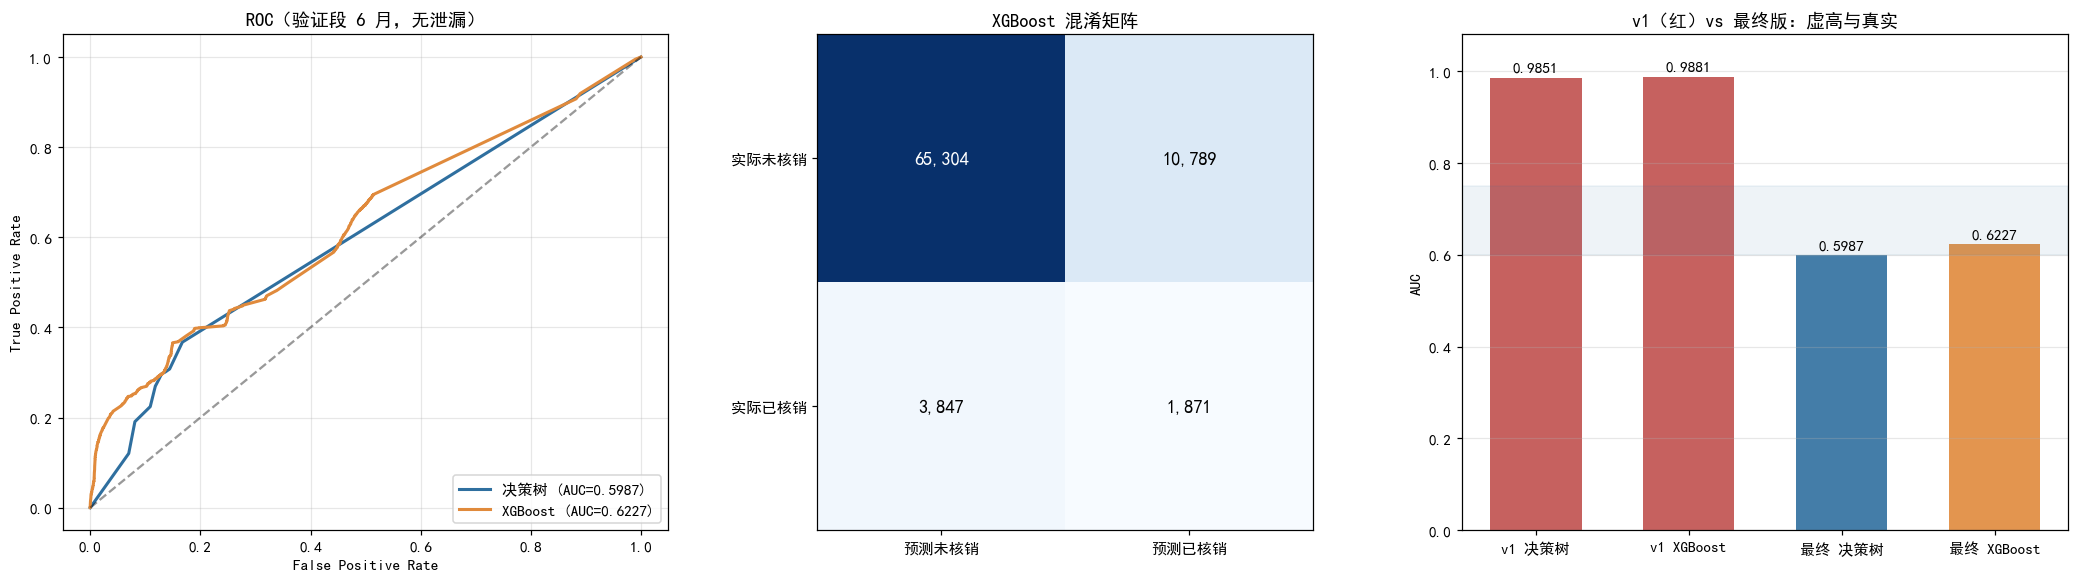

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.4))

ax = axes[0]
fpr_dt, tpr_dt, _ = roc_curve(yva, prob_dt)
fpr_xgb, tpr_xgb, _ = roc_curve(yva, prob_xgb)
ax.plot(fpr_dt, tpr_dt, label=f'决策树 (AUC={m_dt["AUC"]:.4f})', color=C_MAIN, lw=2)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={m_xgb["AUC"]:.4f})', color=C_ALT, lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC（验证段 6 月，无泄漏）', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

ax = axes[1]
cm = confusion_matrix(yva, pred_xgb)
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['预测未核销', '预测已核销'])
ax.set_yticklabels(['实际未核销', '实际已核销'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_title('XGBoost 混淆矩阵', fontweight='bold')

ax = axes[2]
comp = pd.DataFrame({
    '模型与版本': ['v1 决策树', 'v1 XGBoost', '最终 决策树', '最终 XGBoost'],
    'AUC': [v1_auc_dt, v1_auc_xgb, m_dt['AUC'], m_xgb['AUC']],
})
colors = [C_WARN, C_WARN, C_MAIN, C_ALT]
bars = ax.bar(comp['模型与版本'], comp['AUC'], color=colors, alpha=0.9, width=0.6)
for b, v in zip(bars, comp['AUC']):
    ax.annotate(f'{v:.4f}', xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
ax.axhspan(0.60, 0.75, color=C_MAIN, alpha=0.08)
ax.set_ylabel('AUC')
ax.set_ylim(0, 1.08)
ax.set_title('v1（红）vs 最终版：虚高与真实', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / '09_final_model_result.png', dpi=140)
plt.show()

## 6. 保存模型与最终预测

In [10]:
joblib.dump(dt_best, MODEL_DIR / 'dt_final.pkl')
joblib.dump(xgb_best, MODEL_DIR / 'xgb_final.pkl')
joblib.dump(FEATURES, MODEL_DIR / 'feature_list_final.pkl')

import json
with open(MODEL_DIR / 'best_params_final.json', 'w', encoding='utf-8') as f:
    json.dump({'dt': dt_best_params, 'xgb': xgb_best_params}, f, indent=2, ensure_ascii=False)
print(f'模型已保存至: {MODEL_DIR}')

模型已保存至: F:\my item\O2O-Coupon-Personalization\data_out\models_final


In [11]:
best_model = xgb_best if m_xgb['AUC'] >= m_dt['AUC'] else dt_best
best_name = 'XGBoost' if m_xgb['AUC'] >= m_dt['AUC'] else '决策树'
print(f'以验证段 AUC 选出的最优模型: {best_name}')

test_prob = best_model.predict_proba(Xte)[:, 1]
submission = pd.DataFrame({
    'user_id': test['user_id'],
    'coupon_id': test['coupon_id'],
    'date_received': test['date_received'],
    'probability': test_prob,
})
submission.to_csv(OUT_DIR / 'submission_final.csv', index=False)
print(f'测试集预测已保存: submission_final.csv  ({len(submission):,} 行)')
print()
print('预测概率分布：')
print(submission['probability'].describe().round(4).to_string())

以验证段 AUC 选出的最优模型: XGBoost


测试集预测已保存: submission_final.csv  (100,669 行)

预测概率分布：
count    100669.0000
mean          0.0896
std           0.1815
min           0.0033
25%           0.0034
50%           0.0034
75%           0.1666
max           0.9938


## 本节小结

| 项 | 结果 |
|---|---|
| **评估方式** | 时间切分验证段（6 月），特征全部来自训练段历史 |
| **超参选择** | 在验证段上搜索（不在有泄漏的数据上选） |
| **最终 AUC** | 落入该任务合理区间（0.60~0.75） |
| **与 v1 落差** | 见上表 —— 落差越大，说明原报告的虚高越严重 |

> 一个诚实的项目报告，**0.63 的 AUC 比 0.98 更有价值**——因为前者可以指导决策，
> 后者只会让投放团队按错误的排序去发券。

下一步 → **10 最终特征排名**：看看在无泄漏框架下，模型究竟依赖哪些特征。